# Frozen signature overlap audit

This notebook checks the aggregate pre-data artifacts generated from pinned sources. It does **not** contain or infer a biological age effect.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PRE = ROOT / 'results' / 'predata'
assert PRE.exists(), 'Run make predata first'
print(f'Project root: {ROOT}')

Project root: /Users/kyka776/jupyter/GeroScout/initiatives/adipose-senescence-ifn


In [2]:
overlap = pd.read_csv(PRE / 'signature_overlap_summary.tsv', sep='\t')
variants = pd.read_csv(PRE / 'sencat_variant_counts.tsv', sep='\t')
manifest = json.loads((PRE / 'signature_build_manifest.json').read_text())
assert (overlap.overlap_with_sencat <= overlap.mapped_mouse_genes).all()
assert manifest['redistribution']['detailed_sencat_material'] is False
overlap

,axis,source_human_genes,mapped_mouse_genes,unmapped_human_genes,overlap_with_sencat,fraction_of_axis_overlapping_sencat
0,ifng_response,99,72,27,31,0.430556
1,mhcii_antigen_presentation,127,108,19,59,0.546296
2,cell_cycle_arrest,30,29,1,16,0.551724


,variant,mapped_mouse_genes,genes_removed
0,sencat_full,4630,0
1,sencat_minus_ifng,4599,31
2,sencat_minus_mhcii,4571,59
3,sencat_minus_arrest,4614,16
4,sencat_residual,4524,106


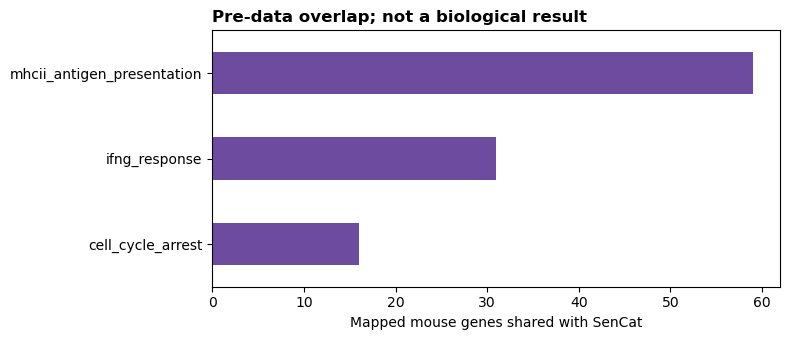

In [3]:
display(variants)
ax = overlap.sort_values('overlap_with_sencat').plot.barh(
    x='axis', y='overlap_with_sencat', legend=False, color='#6D4C9F', figsize=(8, 3.5)
)
ax.set_xlabel('Mapped mouse genes shared with SenCat')
ax.set_ylabel('')
ax.set_title('Pre-data overlap; not a biological result', loc='left', weight='bold')
plt.tight_layout()
plt.show()

Interpretation is deliberately limited: non-zero source overlap makes the preregistered depleted variants necessary. Expression activity and age association remain **not tested** until the matched atlas passes Gate 0.